# 🎯 Integración de Clusters con Modelos de Propensión

**Objetivo**: Combinar segmentación (Tarea 3) con modelos de propensión (Tarea 2)

**Output**:
- Propensión promedio por cluster
- Matriz de estrategia: qué productos ofrecer a cada cluster
- Visualizaciones de distribuciones de propensión

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

## 1. Cargar Datos de Clusters

In [2]:
# Cargar clusters asignados
df_clusters = pd.read_csv('../data/customer_clusters.csv')

print(f"Clientes con cluster: {len(df_clusters):,}")
print(f"\nDistribución de clusters:")
print(df_clusters['cluster_name'].value_counts())
df_clusters.head()

Clientes con cluster: 442,909

Distribución de clusters:
cluster_name
Jóvenes Exploradores       113727
Particulares Activos        86414
Activos Multi-producto      82927
Profesionales Dormidos      65422
Universitarios Estándar     49068
Alto Potencial Virgen       45351
Name: count, dtype: int64


,pk_cid,cluster,cluster_name
0,1000028,5,Particulares Activos
1,1000096,2,Profesionales Dormidos
2,1000113,2,Profesionales Dormidos
3,1000130,2,Profesionales Dormidos
4,1000157,5,Particulares Activos


## 2. Cargar Scores de Propensión

In [3]:
# Cargar scores de pension_plan
try:
    df_pension = pd.read_csv('../../classification_model/data/processed/df_pension_plan_scored.csv')
    print(f"✅ Pension plan scores cargados: {len(df_pension):,} registros")
    has_pension = True
except FileNotFoundError:
    print("⚠️  No se encontró df_pension_plan_scored.csv")
    has_pension = False

# Cargar scores de investment
try:
    df_investment = pd.read_csv('../../classification_model/data/processed/df_inversion_family_scored.csv')
    print(f"✅ Investment scores cargados: {len(df_investment):,} registros")
    has_investment = True
except FileNotFoundError:
    print("⚠️  No se encontró df_inversion_family_scored.csv")
    has_investment = False

✅ Pension plan scores cargados: 423,148 registros
✅ Investment scores cargados: 431,364 registros


## 3. Merge: Clusters + Propensión

In [4]:
# Iniciar con clusters
df_combined = df_clusters.copy()

# Merge con pension plan
if has_pension:
    # Asumir que tiene columnas: pk_cid, propensity_score (o similar)
    pension_cols = df_pension.columns.tolist()
    print(f"Columnas en pension: {pension_cols}")
    
    # Identificar columna de score
    score_col_pension = [c for c in pension_cols if 'score' in c.lower() or 'prob' in c.lower()]
    if score_col_pension:
        score_col_pension = score_col_pension[0]
    else:
        score_col_pension = 'propensity_pension'  # default
    
    # Renombrar para claridad
    df_pension_clean = df_pension[['pk_cid', score_col_pension]].copy()
    df_pension_clean.columns = ['pk_cid', 'propensity_pension']
    
    df_combined = df_combined.merge(df_pension_clean, on='pk_cid', how='left')
    print(f"✅ Merge con pension completado")

# Merge con investment
if has_investment:
    investment_cols = df_investment.columns.tolist()
    print(f"Columnas en investment: {investment_cols}")
    
    score_col_inv = [c for c in investment_cols if 'score' in c.lower() or 'prob' in c.lower()]
    if score_col_inv:
        score_col_inv = score_col_inv[0]
    else:
        score_col_inv = 'propensity_investment'
    
    df_investment_clean = df_investment[['pk_cid', score_col_inv]].copy()
    df_investment_clean.columns = ['pk_cid', 'propensity_investment']
    
    df_combined = df_combined.merge(df_investment_clean, on='pk_cid', how='left')
    print(f"✅ Merge con investment completado")

print(f"\nDataset combinado: {df_combined.shape}")
df_combined.head()

Columnas en pension: ['Unnamed: 0', 'pk_cid', 'propensity_score', 'propensity_segment']
✅ Merge con pension completado
Columnas en investment: ['Unnamed: 0', 'pk_cid', 'short_term_deposit', 'funds', 'securities', 'long_term_deposit', 'have_inversion_products', 'propensity_score', 'propensity_segment']
✅ Merge con investment completado

Dataset combinado: (442909, 5)


,pk_cid,cluster,cluster_name,propensity_pension,propensity_investment
0,1000028,5,Particulares Activos,0.0000,0.0002
1,1000096,2,Profesionales Dormidos,0.0000,0.0001
2,1000113,2,Profesionales Dormidos,0.0000,0.0001
3,1000130,2,Profesionales Dormidos,0.0001,0.0002
4,1000157,5,Particulares Activos,0.0000,0.0000


## 4. Propensión Promedio por Cluster

In [5]:
# Columnas de propensión disponibles
propensity_cols = [c for c in df_combined.columns if 'propensity' in c.lower()]

if propensity_cols:
    # Agrupar por cluster
    propensity_by_cluster = df_combined.groupby(['cluster', 'cluster_name'])[propensity_cols].mean()
    propensity_by_cluster = propensity_by_cluster.round(4)
    
    print("\n📊 PROPENSIÓN PROMEDIO POR CLUSTER\n")
    display(propensity_by_cluster)
    
    # Guardar
    propensity_by_cluster.to_csv('../data/propensity_by_cluster.csv')
    print("\n✅ Guardado en: ../data/propensity_by_cluster.csv")
else:
    print("⚠️  No hay columnas de propensión disponibles")


📊 PROPENSIÓN PROMEDIO POR CLUSTER



,,propensity_pension,propensity_investment
cluster,cluster_name,,
1,Jóvenes Exploradores,0.0187,0.0121
2,Profesionales Dormidos,0.0441,0.0332
3,Activos Multi-producto,0.0128,0.0105
4,Universitarios Estándar,0.0183,0.0160
5,Particulares Activos,0.1309,0.1062
6,Alto Potencial Virgen,0.0379,0.0328



✅ Guardado en: ../data/propensity_by_cluster.csv


## 5. Matriz de Estrategia de Producto

In [6]:
if propensity_cols:
    # Determinar qué producto es más prometedor por cluster
    strategy = []
    
    for cluster_id in sorted(df_combined['cluster'].unique()):
        cluster_name = df_combined[df_combined['cluster']==cluster_id]['cluster_name'].iloc[0]
        cluster_data = df_combined[df_combined['cluster']==cluster_id]
        
        row = {
            'cluster': cluster_id,
            'cluster_name': cluster_name,
            'size': len(cluster_data)
        }
        
        # Propensión promedio por producto
        for prop_col in propensity_cols:
            avg_prop = cluster_data[prop_col].mean()
            row[f'{prop_col}_avg'] = avg_prop
        
        # Producto recomendado (mayor propensión)
        prop_values = {col: cluster_data[col].mean() for col in propensity_cols}
        recommended = max(prop_values, key=prop_values.get)
        row['recommended_product'] = recommended.replace('propensity_', '')
        row['max_propensity'] = prop_values[recommended]
        
        strategy.append(row)
    
    df_strategy = pd.DataFrame(strategy)
    
    print("\n🎯 MATRIZ DE ESTRATEGIA POR CLUSTER\n")
    display(df_strategy)
    
    # Guardar
    df_strategy.to_csv('../data/product_strategy_by_cluster.csv', index=False)
    print("\n✅ Guardado en: ../data/product_strategy_by_cluster.csv")


🎯 MATRIZ DE ESTRATEGIA POR CLUSTER



,cluster,cluster_name,size,propensity_pension_avg,propensity_investment_avg,recommended_product,max_propensity
0,1,Jóvenes Exploradores,113727,0.0187,0.0121,pension,0.0187
1,2,Profesionales Dormidos,65422,0.0441,0.0332,pension,0.0441
2,3,Activos Multi-producto,82927,0.0128,0.0105,pension,0.0128
3,4,Universitarios Estándar,49068,0.0183,0.0160,pension,0.0183
4,5,Particulares Activos,86414,0.1309,0.1062,pension,0.1309
5,6,Alto Potencial Virgen,45351,0.0379,0.0328,pension,0.0379



✅ Guardado en: ../data/product_strategy_by_cluster.csv


## 6. Heatmap de Propensión por Cluster

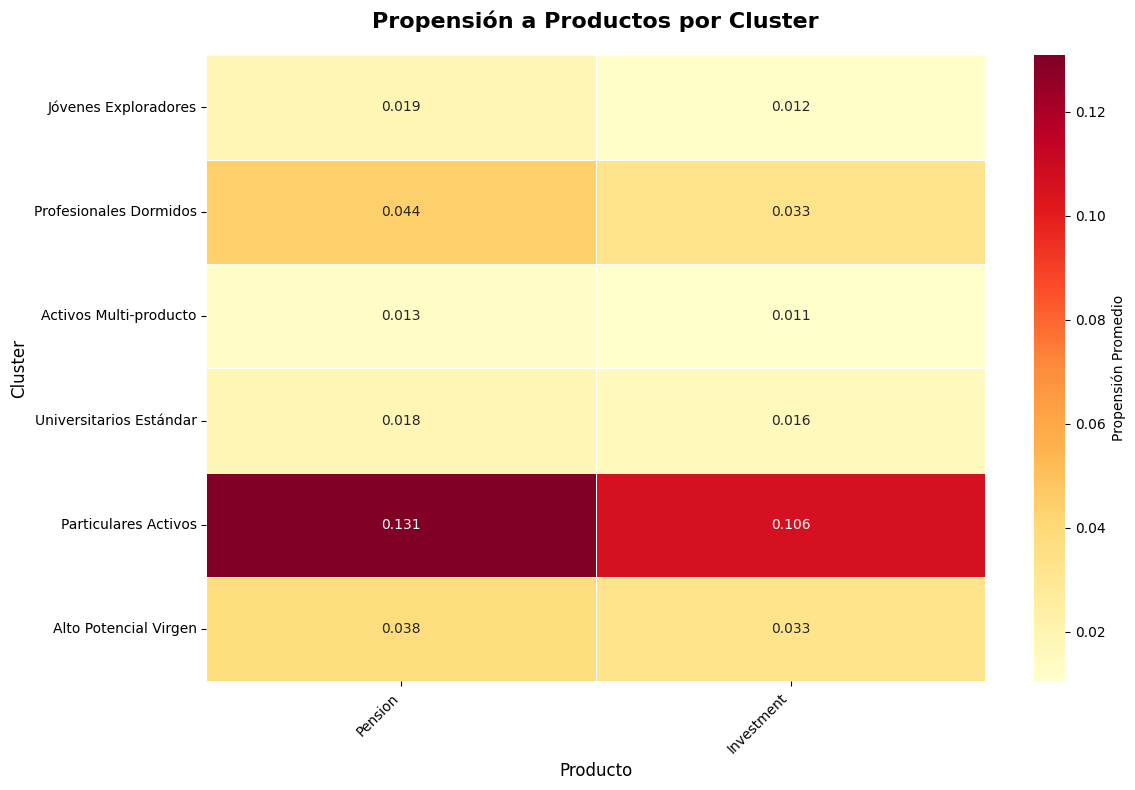

✅ Heatmap guardado en: ../visualizations/propensity_heatmap.png


In [7]:
if propensity_cols and len(propensity_cols) > 0:
    # Preparar datos para heatmap
    heatmap_data = propensity_by_cluster.copy()
    heatmap_data.index = heatmap_data.index.get_level_values('cluster_name')
    
    # Renombrar columnas para legibilidad
    heatmap_data.columns = [c.replace('propensity_', '').replace('_', ' ').title() for c in heatmap_data.columns]
    
    # Crear heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.3f',
        cmap='YlOrRd',
        cbar_kws={'label': 'Propensión Promedio'},
        linewidths=0.5
    )
    plt.title('Propensión a Productos por Cluster', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Cluster', fontsize=12)
    plt.xlabel('Producto', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('../visualizations/propensity_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Heatmap guardado en: ../visualizations/propensity_heatmap.png")

## 7. Distribuciones de Propensión por Cluster

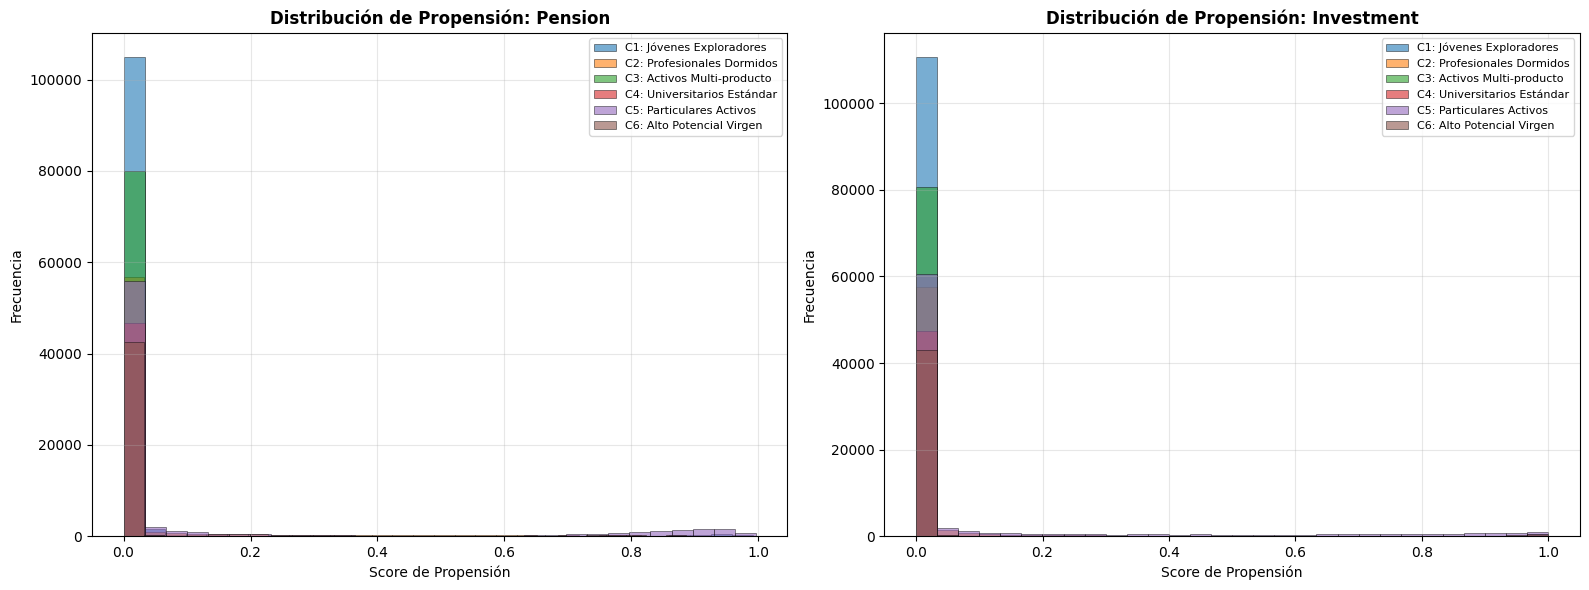

✅ Distribuciones guardadas en: ../visualizations/propensity_distributions.png


In [8]:
if propensity_cols:
    n_products = len(propensity_cols)
    n_cols = min(2, n_products)
    n_rows = (n_products + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6*n_rows))
    if n_products == 1:
        axes = [axes]
    else:
        axes = axes.ravel()
    
    for idx, prop_col in enumerate(propensity_cols):
        ax = axes[idx]
        
        for cluster_id in sorted(df_combined['cluster'].unique()):
            cluster_data = df_combined[df_combined['cluster'] == cluster_id][prop_col].dropna()
            cluster_name = df_combined[df_combined['cluster']==cluster_id]['cluster_name'].iloc[0]
            
            ax.hist(
                cluster_data,
                alpha=0.6,
                label=f'C{cluster_id}: {cluster_name}',
                bins=30,
                edgecolor='black',
                linewidth=0.5
            )
        
        product_name = prop_col.replace('propensity_', '').replace('_', ' ').title()
        ax.set_title(f'Distribución de Propensión: {product_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Score de Propensión', fontsize=10)
        ax.set_ylabel('Frecuencia', fontsize=10)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # Ocultar ejes vacíos si hay número impar
    for idx in range(n_products, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('../visualizations/propensity_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Distribuciones guardadas en: ../visualizations/propensity_distributions.png")

## 8. Top Clientes por Cluster y Producto

In [9]:
if propensity_cols:
    # Para cada producto, identificar top N clientes por cluster
    top_n = 100  # Top 100 por cluster
    
    top_customers = {}
    
    for prop_col in propensity_cols:
        product_name = prop_col.replace('propensity_', '')
        top_customers[product_name] = []
        
        for cluster_id in sorted(df_combined['cluster'].unique()):
            cluster_data = df_combined[df_combined['cluster'] == cluster_id].copy()
            cluster_data = cluster_data.dropna(subset=[prop_col])
            
            # Top N del cluster
            top_cluster = cluster_data.nlargest(top_n, prop_col)[['pk_cid', 'cluster', 'cluster_name', prop_col]]
            top_customers[product_name].append(top_cluster)
        
        # Combinar todos los clusters
        df_top = pd.concat(top_customers[product_name], ignore_index=True)
        
        # Guardar
        output_path = f'../data/top_customers_{product_name}.csv'
        df_top.to_csv(output_path, index=False)
        print(f"✅ Top {len(df_top):,} clientes para {product_name}: {output_path}")
    
    print(f"\n📋 Total de archivos de targeting creados: {len(propensity_cols)}")

✅ Top 600 clientes para pension: ../data/top_customers_pension.csv
✅ Top 600 clientes para investment: ../data/top_customers_investment.csv

📋 Total de archivos de targeting creados: 2


## 9. Resumen Ejecutivo

In [10]:
if propensity_cols:
    print("="*70)
    print("📊 RESUMEN EJECUTIVO: INTEGRACIÓN CLUSTERING + PROPENSIÓN")
    print("="*70)
    print()
    print(f"Total de clientes analizados: {len(df_combined):,}")
    print(f"Número de clusters: {df_combined['cluster'].nunique()}")
    print(f"Productos con modelo de propensión: {len(propensity_cols)}")
    print()
    print("="*70)
    print("🎯 RECOMENDACIONES POR CLUSTER")
    print("="*70)
    
    for _, row in df_strategy.iterrows():
        print(f"\n{row['cluster_name']} (Cluster {row['cluster']}) - {row['size']:,} clientes")
        print(f"  └─ Producto recomendado: {row['recommended_product'].upper()}")
        print(f"     Propensión promedio: {row['max_propensity']:.2%}")
        print(f"     Potencial campaña: {int(row['size'] * row['max_propensity']):,} conversiones estimadas")
    
    print("\n" + "="*70)
    print("✅ ANÁLISIS COMPLETADO")
    print("="*70)
else:
    print("⚠️  No hay datos de propensión para analizar")

📊 RESUMEN EJECUTIVO: INTEGRACIÓN CLUSTERING + PROPENSIÓN

Total de clientes analizados: 442,909
Número de clusters: 6
Productos con modelo de propensión: 2

🎯 RECOMENDACIONES POR CLUSTER

Jóvenes Exploradores (Cluster 1) - 113,727 clientes
  └─ Producto recomendado: PENSION
     Propensión promedio: 1.87%
     Potencial campaña: 2,123 conversiones estimadas

Profesionales Dormidos (Cluster 2) - 65,422 clientes
  └─ Producto recomendado: PENSION
     Propensión promedio: 4.41%
     Potencial campaña: 2,888 conversiones estimadas

Activos Multi-producto (Cluster 3) - 82,927 clientes
  └─ Producto recomendado: PENSION
     Propensión promedio: 1.28%
     Potencial campaña: 1,058 conversiones estimadas

Universitarios Estándar (Cluster 4) - 49,068 clientes
  └─ Producto recomendado: PENSION
     Propensión promedio: 1.83%
     Potencial campaña: 896 conversiones estimadas

Particulares Activos (Cluster 5) - 86,414 clientes
  └─ Producto recomendado: PENSION
     Propensión promedio: 13.09%

---

## ✅ INTEGRACIÓN COMPLETADA

### Archivos generados:
1. **propensity_by_cluster.csv**: Propensión promedio por cluster y producto
2. **product_strategy_by_cluster.csv**: Matriz de estrategia con producto recomendado
3. **top_customers_[producto].csv**: Listas de targeting por producto
4. **Visualizaciones**:
   - propensity_heatmap.png
   - propensity_distributions.png

### Valor de negocio:
- ✅ Segmentación + Propensión = Targeting preciso
- ✅ Cada cluster tiene una estrategia de producto clara
- ✅ Listas de clientes listas para campañas

### 🎉 TAREA 3 (CLUSTERING) MEJORADA Y COMPLETADA